In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [ ]:
uploaded=files.upload()
df=pd.read_csv('heart.csv')
df.head()

Saving heart.csv to heart.csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


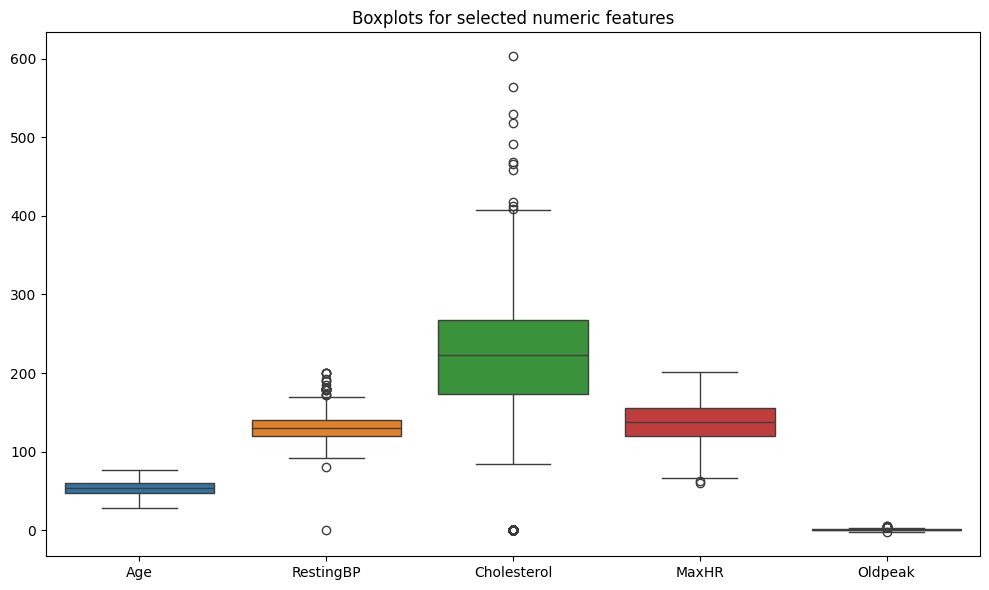

In [ ]:
from csv import field_size_limit
numerical_cols=["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

plt.figure(figsize=(10,6))
sns.boxplot(data=df[numerical_cols])
plt.title("Boxplots for selected numeric features")
plt.tight_layout()
plt.show()

In [ ]:
# use IQR method on Cholesterol
col="Cholesterol"
Q1= df[col].quantile(0.25)
Q3= df[col].quantile(0.75)
IQR= Q3-Q1

lower= Q1 - 1.5*IQR
upper= Q3 + 1.5*IQR

outliers= df[(df[col]<lower) | (df[col]>upper)]

print(f"Number of outliers in {col}: {len(outliers)}")

Number of outliers in Cholesterol: 183


In [ ]:
for o in numerical_cols:
  Q1=df[o].quantile(0.25)
  Q3=df[o].quantile(0.75)

  lower= Q1 - 1.5*IQR
  upper= Q3 + 1.5*IQR

  outliers= df[(df[o]<lower) | (df[o]>upper)]
  print(f"Number of outliers in {o}: {len(outliers)}")



Number of outliers in Age: 0
Number of outliers in RestingBP: 28
Number of outliers in Cholesterol: 300
Number of outliers in MaxHR: 36
Number of outliers in Oldpeak: 0


# Outliers Handle

In [ ]:
# 1. Remove outliers
df_no_outliers=df[(df[col]>=lower) & (df[col]<=upper)] # lower এর থেকে উপরের আর upper এর থেকে নিচের value গুলা নিচ্ছি, যার ফলে auto outlers remove হয়ে যাচ্ছে
print(f"Remove outliers: {len(df_no_outliers)}") # অনেক বড় dataset থাকলে use করা ভালো

# Cap outliers (Winsorization like approach)  lower এর নিচের value গুলাকে lower আর upper এর উপরের value গুলাকে upper এর value দ্বারা replace করে দিচ্ছি
df_capped= df.copy()
df_capped= df_capped[col].clip(lower,upper) # use করা বেশি ভালো না, অনেক সময় feature এর বৈশিস্ট নষ্ট হয়
print(f"Capping: {len(df_capped)}")

# Log transform the column (for skewed distributions)  log apply করে সব value গুলাকে খুব কাছাকাছি ছোট value তে নিয়ে আসে
df_log= df.copy() # এটা use করা বেশি ভালো
df_log[col+"_log"]=np.log(df_log[col]+1) # log(0) এর মান 0 , যার ফলে inf value চলে আসতে পারে, তাই সব value এর সাথে 1 add করছি। এর ফলে value তে তেমন পরিবতন আসে না
print(f"Log transform: {len(df_log)}")

Remove outliers: 735
Capping: 918
Log transform: 918
